In [1]:
pwd

'D:\\樓上志偉\\2025實測\\notebooks'

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sns

pd.options.mode.copy_on_write = True
fm.fontManager.addfont('..\\TaipeiSansTCBeta-Regular.ttf')
plt.rcParams["font.size"] = 14
plt.rcParams['font.family'] = 'Taipei Sans TC Beta'

In [3]:
df_source = pd.read_csv('..\\data\\raw\\偉仁26噸\\B114AS0005_0327_FUEL_CONSUMPTION_HALF_LOAD_1ST.csv', header=2)
# df_source = pd.read_csv('..\\data\\raw\\偉仁26噸\\B114AS0005_0327_FUEL_CONSUMPTION_FULL_LOAD_1ST.csv', header=2)
print(df_source.columns)
df_source.head()

Index(['Absolute_time', 'Relative_time', 'SYS_TestSequenceNumber',
       'SYS_TestStatus', 'SYS_TestRunStatus', 'SYS_TestResultStatus',
       'SYS_TestTime', 'SYS_TestDistance', 'SYS_PhaseNo', 'SYS_PhaseTime',
       'SYS_TotalPhaseTime', 'GPS_GPSStatus', 'GPS_Altitude', 'GPS_Latitude',
       'GPS_Longitude', 'GPS_VehicleSpeed', 'GPS_Course', 'GPS_GPSSatelliteId',
       'GPS_GPSNumberOfSatellite', 'BT_BatteryVoltage', 'WS_AmbientTemp',
       'WS_AmbientRelativeHumidity', 'WS_AmbientPressure',
       'PF_ExhaustFlowRate', 'PF_ExhaustFlowRate1', 'PF_ExhaustTemp1',
       'PF_ExhaustPressure1', 'PF_ExhaustFlowRate2', 'PF_ExhaustTemp2',
       'PF_ExhaustPressure2', 'PF_ExhaustDiffPressure1',
       'PF_ExhaustDiffPressure2', 'GA_Operation', 'GA_Sequence', 'GA_COConc',
       'GA_CO2Conc', 'GA_H2OConc', 'GA_NOConc', 'GA_NOxConc', 'GA_NO2Conc',
       'OBD_EngineCoolantTemp', 'OBD_EngineSpeed', 'OBD_VehicleSpeed',
       'OBD_IntakeAirTemp', 'OBD_MassAirFlowRate', 'OBD_CommandedEGR',
 

,Absolute_time,Relative_time,SYS_TestSequenceNumber,SYS_TestStatus,SYS_TestRunStatus,SYS_TestResultStatus,SYS_TestTime,SYS_TestDistance,SYS_PhaseNo,SYS_PhaseTime,...,TailpipeAmbientRelativeHumidity,TailpipeAmbientAbsoluteHumidity,OBDCalculatedLOADValue,OBDEngineFrictionPercentTorque,OBDEngineCoolantTemp1,OBDDriversDemandEnginePercentTorque,OBDEngineFuelRate_1,OBDEngineFuelRate_2,OBDVehicleFuelRate,VehicleSpeed_Max
0,03/27/2025 09:21:39.6045761,0,9251,1,32,0,925.1,0.023458,1,0.0,...,54.200001,2.548754,22.352942,7,83,0,1.55,0,0,0.020
1,03/27/2025 09:21:40.5945663,1,9261,1,32,0,926.1,0.023488,1,1.0,...,54.200001,2.548754,26.666666,7,83,31,2.30,0,0,0.134
2,03/27/2025 09:21:41.5985794,2,9271,1,32,0,927.1,0.023557,1,2.0,...,54.200001,2.548754,28.627451,8,83,53,3.75,0,0,0.602
3,03/27/2025 09:21:42.5945663,3,9281,1,32,0,928.1,0.024068,1,3.0,...,54.100002,2.544051,69.411766,9,83,49,11.80,0,0,3.288
4,03/27/2025 09:21:43.5945663,4,9291,1,32,0,929.1,0.025264,1,4.0,...,54.100002,2.544051,74.509804,10,83,38,20.60,0,0,5.707


In [4]:
df_source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5556 entries, 0 to 5555
Data columns (total 66 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Absolute_time                        5556 non-null   object 
 1   Relative_time                        5556 non-null   int64  
 2   SYS_TestSequenceNumber               5556 non-null   int64  
 3   SYS_TestStatus                       5556 non-null   int64  
 4   SYS_TestRunStatus                    5556 non-null   int64  
 5   SYS_TestResultStatus                 5556 non-null   int64  
 6   SYS_TestTime                         5556 non-null   float64
 7   SYS_TestDistance                     5556 non-null   float64
 8   SYS_PhaseNo                          5556 non-null   int64  
 9   SYS_PhaseTime                        5556 non-null   float64
 10  SYS_TotalPhaseTime                   5556 non-null   float64
 11  GPS_GPSStatus                 

In [5]:
df_source['GPS_GPSNumberOfSatellite'].value_counts()

GPS_GPSNumberOfSatellite
9     2142
10    2059
8      515
11     457
12     319
7       55
6        9
Name: count, dtype: int64

In [6]:
df_source['OBD_DPF_Regeneration_Status'].value_counts()

OBD_DPF_Regeneration_Status
0    5556
Name: count, dtype: int64

In [7]:
df = df_source[['GPS_VehicleSpeed', 'OBD_EngineSpeed', 'OBD_EngineFuelRate']]
df.columns = ['VehicleSpeed[km/h]', 'EngineSpeed[rpm]', 'EngineFuelRate[L/h]']

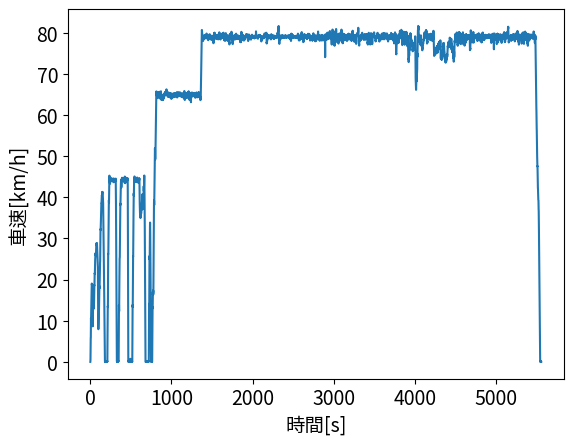

In [8]:
df['time[s]'] = [i for i in range(1, len(df)+1)]

fig = plt.figure() 
plt.plot(df['time[s]'], df['VehicleSpeed[km/h]']) 
plt.xlabel('時間[s]')
plt.ylabel('車速[km/h]')
plt.show()

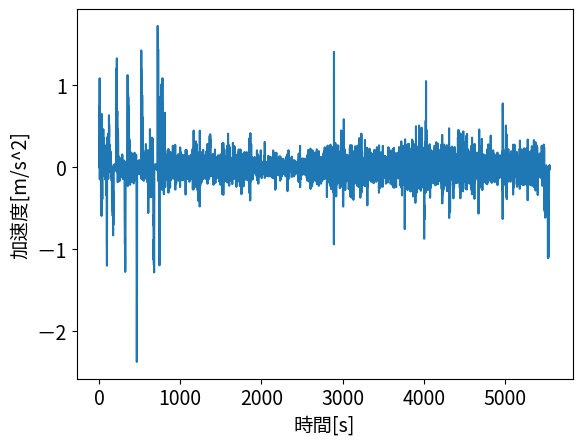

In [9]:
df['acc[m/s^2]'] = 0.
for i in range(1,len(df)):
    df.loc[i, 'acc[m/s^2]'] = (df.loc[i,'VehicleSpeed[km/h]'] - df.loc[i-1,'VehicleSpeed[km/h]']) / 3.6 # 逐秒資料

fig = plt.figure() 
plt.plot(df['time[s]'], df['acc[m/s^2]']) 
plt.xlabel('時間[s]')
plt.ylabel('加速度[m/s^2]')
plt.show()

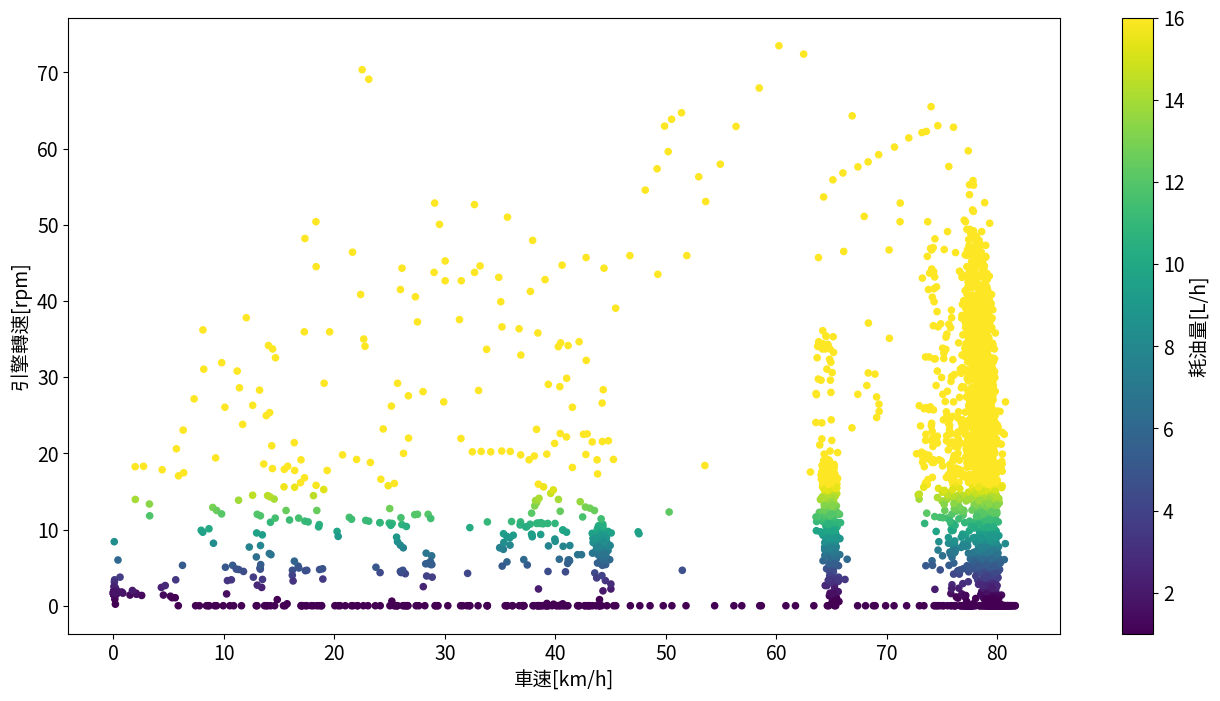

In [10]:
fig, ax = plt.subplots(figsize=(16, 8))
norm = matplotlib.colors.Normalize(vmin=1, vmax=16)
sc = ax.scatter(df['VehicleSpeed[km/h]'], df['EngineFuelRate[L/h]'], c=df['EngineFuelRate[L/h]'], cmap='viridis', s=20, norm=norm)
ax.set_xlabel('車速[km/h]')
ax.set_ylabel('引擎轉速[rpm]')
# ax.set_xlim(0,5500)
# ax.set_ylim(0,85)
# plt.title("依車速、引擎轉速判斷變速箱操作檔位")
plt.colorbar(sc, label='耗油量[L/h]')

plt.show()

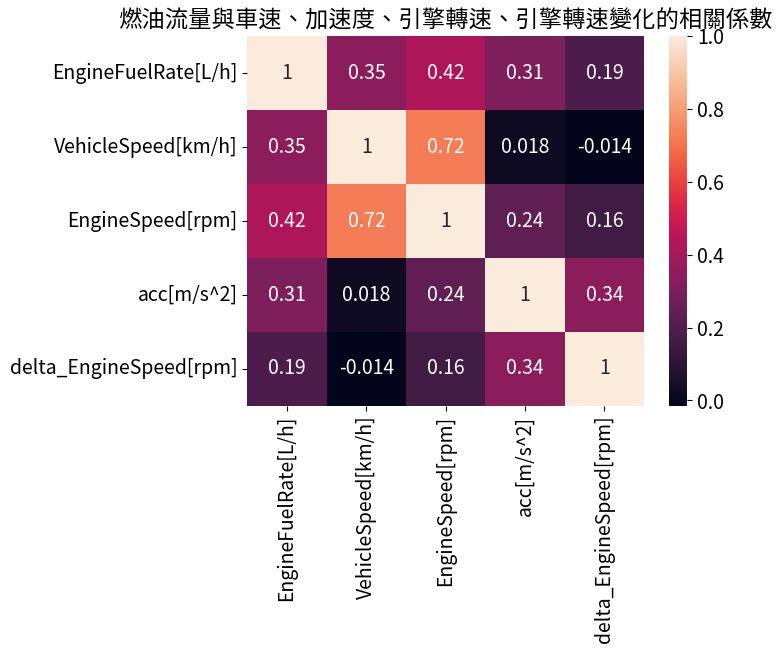

In [11]:
df['delta_EngineSpeed[rpm]'] = 0.
for i in range(1,len(df)):
    df.loc[i, 'delta_EngineSpeed[rpm]'] = df.loc[i,'EngineSpeed[rpm]'] - df.loc[i-1,'EngineSpeed[rpm]']

sns.heatmap(df[['EngineFuelRate[L/h]', 'VehicleSpeed[km/h]', 'EngineSpeed[rpm]', 'acc[m/s^2]', 'delta_EngineSpeed[rpm]']].corr(), annot=True)
plt.title("燃油流量與車速、加速度、引擎轉速、引擎轉速變化的相關係數")
plt.show()

In [12]:
df.describe()

,VehicleSpeed[km/h],EngineSpeed[rpm],EngineFuelRate[L/h],time[s],acc[m/s^2],delta_EngineSpeed[rpm]
count,5556.000000,5556.000000,5.556000e+03,5556.000000,5556.000000,5556.000000
mean,69.047832,1151.460583,1.783716e+01,2778.500000,0.000002,-0.000045
std,20.093874,161.634486,1.149676e+01,1604.023379,0.196436,51.309161
min,0.004000,441.500000,-4.440000e-16,1.000000,-2.378611,-770.000000
25%,65.380003,1169.750000,9.100000e+00,1389.750000,-0.066388,-4.250000
50%,78.629997,1211.250000,1.790000e+01,2778.500000,0.000555,0.250000
75%,79.087248,1217.250000,2.381250e+01,4167.250000,0.067848,4.500000
max,81.638000,1938.500000,7.350000e+01,5556.000000,1.724445,608.750000


##### **車速與引擎轉速二維分組的燃油流量以平均數為代表**
##### **燃油流量大於等於零(可電子斷油，而不是考慮車輛怠速/引擎惰轉的耗油量)**

In [13]:
EFR_idling = df[df['VehicleSpeed[km/h]']<0.5]['EngineFuelRate[L/h]'].median()
EFR_idling

np.float64(1.75)

In [14]:
from sklearn.linear_model import LinearRegression

spacing_nn = [2, 3, 4, 5, 6, 7, 8, 9, 10]
r2_scores = {}

for nn in spacing_nn:
    VSn = np.linspace(df['VehicleSpeed[km/h]'].min(), df['VehicleSpeed[km/h]'].max(), nn+1)
    ESn = np.linspace(df['EngineSpeed[rpm]'].min(), df['EngineSpeed[rpm]'].max(), nn+1)
    dfGG = df.groupby([pd.cut(df['VehicleSpeed[km/h]'], bins=VSn), pd.cut(df['EngineSpeed[rpm]'], bins=ESn)], observed=True)['EngineFuelRate[L/h]'].agg(['count', 'mean']).reset_index()
   
    dfGG['VehicleSpeed[km/h]'] = dfGG['VehicleSpeed[km/h]'].apply(lambda x: (x.left+x.right)/2)
    dfGG['EngineSpeed[rpm]'] = dfGG['EngineSpeed[rpm]'].apply(lambda x: (x.left+x.right)/2)
    # dfGG = dfGG[dfGG['mean']>0] # 加入人工判斷
    
    X = dfGG[['VehicleSpeed[km/h]', 'EngineSpeed[rpm]']]
    y = dfGG['mean']
    
    reg = LinearRegression().fit(X, y)
    print(f"車速與引擎轉速分組為{nn}x{nn}下，迴歸的R2為{reg.score(X, y):.4f}")


車速與引擎轉速分組為2x2下，迴歸的R2為0.8379
車速與引擎轉速分組為3x3下，迴歸的R2為0.8862
車速與引擎轉速分組為4x4下，迴歸的R2為0.3701
車速與引擎轉速分組為5x5下，迴歸的R2為0.7015
車速與引擎轉速分組為6x6下，迴歸的R2為0.7334
車速與引擎轉速分組為7x7下，迴歸的R2為0.6711
車速與引擎轉速分組為8x8下，迴歸的R2為0.4098
車速與引擎轉速分組為9x9下，迴歸的R2為0.3948
車速與引擎轉速分組為10x10下，迴歸的R2為0.4369


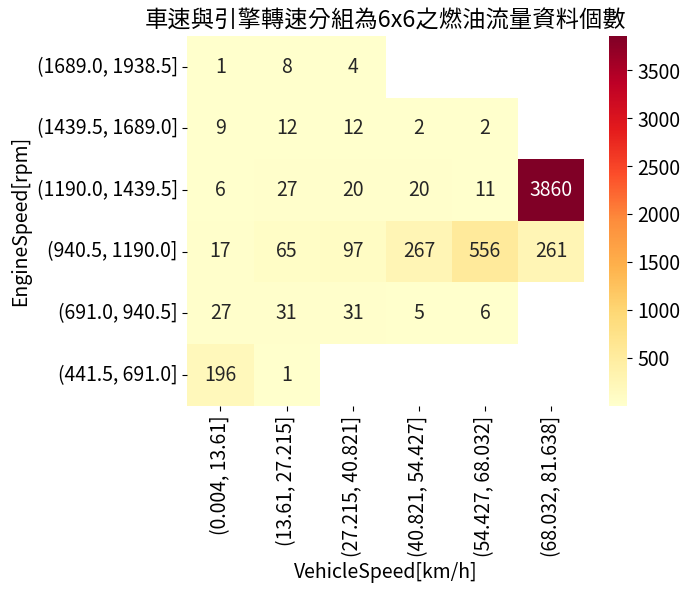

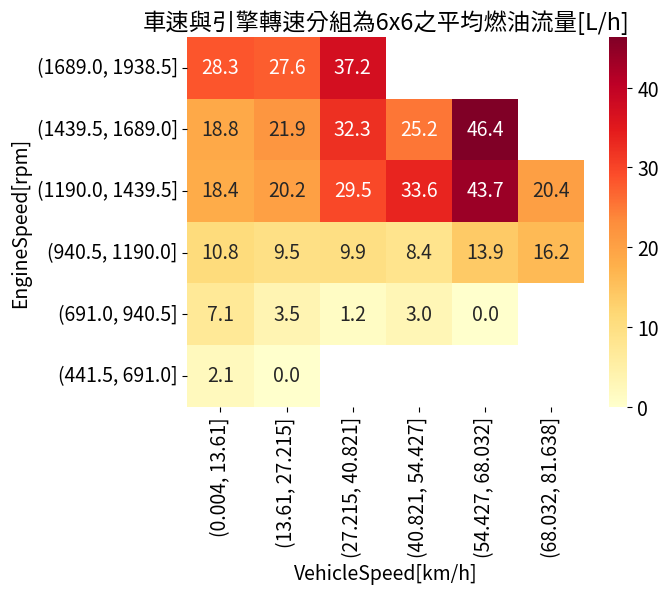

車速與引擎轉速分組為6x6下，迴歸的R2為0.7334
[0.14482437 0.03017559]
-23.418576747674436


In [15]:
from sklearn.linear_model import LinearRegression

nn=6 # HALF_LOAD & FULL_LOAD

VSn = np.linspace(df['VehicleSpeed[km/h]'].min(), df['VehicleSpeed[km/h]'].max(), nn+1)
ESn = np.linspace(df['EngineSpeed[rpm]'].min(), df['EngineSpeed[rpm]'].max(), nn+1)
dfGG = df.groupby([pd.cut(df['VehicleSpeed[km/h]'], bins=VSn), pd.cut(df['EngineSpeed[rpm]'], bins=ESn)], observed=True)['EngineFuelRate[L/h]'].agg(['count', 'mean']).reset_index()

pivot_table_count = dfGG.pivot(index='EngineSpeed[rpm]', columns='VehicleSpeed[km/h]', values='count')
plt.figure()
ax = sns.heatmap(pivot_table_count, annot=True, fmt='.0f', cmap='YlOrRd')
ax.invert_yaxis()
plt.title(f"車速與引擎轉速分組為{nn}x{nn}之燃油流量資料個數")
plt.show()

pivot_table_mean = dfGG.pivot(index='EngineSpeed[rpm]', columns='VehicleSpeed[km/h]', values='mean')
plt.figure()
ax = sns.heatmap(pivot_table_mean, annot=True, fmt='.1f', cmap='YlOrRd')
ax.invert_yaxis()
plt.title(f"車速與引擎轉速分組為{nn}x{nn}之平均燃油流量[L/h]")
plt.show()

dfGG['VehicleSpeed[km/h]'] = dfGG['VehicleSpeed[km/h]'].apply(lambda x: (x.left+x.right)/2)
dfGG['EngineSpeed[rpm]'] = dfGG['EngineSpeed[rpm]'].apply(lambda x: (x.left+x.right)/2)
# dfGG = dfGG[dfGG['mean']>0] # 加入人工判斷

X = dfGG[['VehicleSpeed[km/h]', 'EngineSpeed[rpm]']]
y = dfGG['mean']

reg = LinearRegression().fit(X, y)
print(f"車速與引擎轉速分組為{nn}x{nn}下，迴歸的R2為{reg.score(X, y):.4f}")
print(reg.coef_)
print(reg.intercept_)


In [16]:
dfGG.to_csv(f'..//models//model_5_dfGG_{nn}x{nn}_HALF_LOAD.csv', encoding= 'utf-8-sig', index=False)
# dfGG.to_csv(f'..//models//model_5_dfGG_{nn}x{nn}_FULL_LOAD.csv', encoding= 'utf-8-sig', index=False)

In [17]:
import pickle

with open(f'..//models//model_5_spacing_{nn}x{nn}_HALF_LOAD.pkl', 'wb') as f:
# with open(f'..//models//model_5_spacing_{nn}x{nn}_FULL_LOAD.pkl', 'wb') as f:
    pickle.dump(reg, f)